# Step 5 — SHAP Explainability for the TensorFlow Survival Model

This notebook explains the **trained multimodal survival model** using SHAP.

We focus on one clinically interpretable target:

> **5-year failure risk = 1 - S(60 months)**

The notebook reconstructs the same preprocessing and patient split used during training, loads the saved Keras model, and estimates feature contributions for:

- static valve/patient features,
- longitudinal physiology/hemodynamics,
- longitudinal medications.

## Important interpretation note

These explanations describe what the model learned from the **synthetic dataset**.  
They are useful for model understanding and presentation, but they are **not clinical causal effects**.

Because the model contains GRUs and multiple inputs, SHAP is more computationally expensive than for a simple tabular model. We therefore explain a moderate sample of test patients.


In [1]:
from pathlib import Path
import json
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Install SHAP only if it is missing.
try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_CSV = Path("synthetic_generator_outputs_v2/synthetic_multimodal_patient_year_v2_MODEL_READY.csv")
SPEC_JSON = Path("synthetic_generator_outputs_v2/encoder_input_spec_v2.json")
MODEL_PATH = Path("model_outputs_tensorflow_v1/multimodal_valve_survival_model_v1.keras")

print("TensorFlow:", tf.__version__)
print("SHAP:", shap.__version__)
print("Model:", MODEL_PATH.resolve())


c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.10.0
SHAP: 0.49.1
Model: C:\Users\User\OneDrive\Υπολογιστής\πανεπιστημιο\workstation\docathon\model_outputs_tensorflow_v1\multimodal_valve_survival_model_v1.keras


## 1. Load data, specification and trained model

In [2]:
df = pd.read_csv(DATA_CSV)

with open(SPEC_JSON, "r", encoding="utf-8") as f:
    spec = json.load(f)

PATIENT_COL = spec["patient_id_column"]
TIME_COL = spec["time_column"]

STATIC_FEATURES = [
    c for c in spec["static_features"]
    if c != "valve_position"
]

PHYS_FEATURES = spec["physiology_features"]
MED_FEATURES = spec["medication_features"]
NOTE_FEATURES = spec.get("note_derived_features_v1_optional", [])

# We only need inference, so compile=False avoids needing to reload the custom survival loss.
model = keras.models.load_model(MODEL_PATH, compile=False)

print("Dataset shape:", df.shape)
print("Patients:", df[PATIENT_COL].nunique())
model.summary()


Dataset shape: (7169, 67)
Patients: 1000
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 phys_input (InputLayer)        [(None, None, 71)]   0           []                               
                                                                                                  
 med_input (InputLayer)         [(None, None, 31)]   0           []                               
                                                                                                  
 masking_2 (Masking)            (None, None, 71)     0           ['phys_input[0][0]']             
                                                                                                  
 masking_3 (Masking)            (None, None, 31)     0           ['med_input[0][0]']              
                                                   

## 2. Recreate the same patient-level split

In [3]:
patient_table = (
    df[[PATIENT_COL, "event", "duration_months"]]
    .drop_duplicates(PATIENT_COL)
    .reset_index(drop=True)
)

g1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=SEED,
)

tr_idx, tmp_idx = next(
    g1.split(patient_table, groups=patient_table[PATIENT_COL])
)

train_patients = patient_table.iloc[tr_idx][PATIENT_COL].tolist()
tmp = patient_table.iloc[tmp_idx].reset_index(drop=True)

g2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=SEED + 1,
)

va_idx, te_idx = next(
    g2.split(tmp, groups=tmp[PATIENT_COL])
)

val_patients = tmp.iloc[va_idx][PATIENT_COL].tolist()
test_patients = tmp.iloc[te_idx][PATIENT_COL].tolist()

print("Train:", len(train_patients))
print("Validation:", len(val_patients))
print("Test:", len(test_patients))


Train: 700
Validation: 150
Test: 150


## 3. Refit preprocessing on training patients only

In [4]:
train_df = df[df[PATIENT_COL].isin(train_patients)].copy()

STATIC_NUMERIC = [
    c for c in STATIC_FEATURES
    if pd.api.types.is_numeric_dtype(train_df[c])
]

STATIC_CATEGORICAL = [
    c for c in STATIC_FEATURES
    if c not in STATIC_NUMERIC
]

static_rows = (
    train_df
    .sort_values([PATIENT_COL, TIME_COL])
    .groupby(PATIENT_COL)
    .first()
    .reset_index()
)

static_scaler = StandardScaler().fit(
    static_rows[STATIC_NUMERIC].astype(float)
)

try:
    static_ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
    )
except TypeError:
    static_ohe = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False,
    )

static_ohe.fit(
    static_rows[STATIC_CATEGORICAL].astype(str)
)

phys_train = train_df[PHYS_FEATURES].apply(
    pd.to_numeric,
    errors="coerce",
)

phys_mean = phys_train.mean().fillna(0.0)
phys_std = phys_train.std().replace(0, 1.0).fillna(1.0)

TIME_SCALE = max(float(train_df[TIME_COL].max()), 1.0)

print("Static numeric:", STATIC_NUMERIC)
print("Static categorical:", STATIC_CATEGORICAL)


Static numeric: ['valve_size_mm', 'age_at_implant', 'ckd', 'af', 'heart_failure', 'diabetes']
Static categorical: ['procedure_type', 'valve_model', 'sex']


## 4. Build model inputs

In [5]:
def transform_static(pdf):
    first = pdf.sort_values(TIME_COL).iloc[0]

    num = first[STATIC_NUMERIC].astype(float).to_numpy().reshape(1, -1)
    num = static_scaler.transform(num)

    cat = first[STATIC_CATEGORICAL].astype(str).to_numpy().reshape(1, -1)
    cat = static_ohe.transform(cat)

    return np.concatenate([num, cat], axis=1).astype(np.float32).squeeze(0)


def transform_phys(pdf):
    pdf = pdf.sort_values(TIME_COL)

    vals = pdf[PHYS_FEATURES].apply(pd.to_numeric, errors="coerce")
    mask = vals.notna().astype(np.float32)

    z = ((vals - phys_mean) / phys_std).fillna(0.0).astype(np.float32)

    parts = [
        z.to_numpy(),
        mask.to_numpy(),
    ]

    if NOTE_FEATURES:
        note_values = (
            pdf[NOTE_FEATURES]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0.0)
            .astype(np.float32)
            .to_numpy()
        )
        parts.append(note_values)

    time_channel = (
        pdf[TIME_COL]
        .astype(float)
        .to_numpy()
        .reshape(-1, 1)
        / TIME_SCALE
    ).astype(np.float32)

    parts.append(time_channel)

    return np.concatenate(parts, axis=1).astype(np.float32)


def transform_med(pdf):
    pdf = pdf.sort_values(TIME_COL)

    vals = pdf[MED_FEATURES].apply(pd.to_numeric, errors="coerce")
    mask = vals.notna().astype(np.float32)
    filled = vals.fillna(0.0).astype(np.float32)

    time_channel = (
        pdf[TIME_COL]
        .astype(float)
        .to_numpy()
        .reshape(-1, 1)
        / TIME_SCALE
    ).astype(np.float32)

    return np.concatenate(
        [
            filled.to_numpy(),
            mask.to_numpy(),
            time_channel,
        ],
        axis=1,
    ).astype(np.float32)


def make_sample(pid):
    pdf = df[df[PATIENT_COL] == pid].sort_values(TIME_COL)

    return {
        "pid": str(pid),
        "xs": transform_static(pdf),
        "xp": transform_phys(pdf),
        "xm": transform_med(pdf),
        "duration": float(pdf["duration_months"].iloc[0]),
        "event": int(pdf["event"].iloc[0]),
    }


# Use one common padding length for SHAP background and explained samples.
ALL_IDS = train_patients + val_patients + test_patients
GLOBAL_MAX_T = int(
    max(
        df[df[PATIENT_COL] == pid].shape[0]
        for pid in ALL_IDS
    )
)

print("Global max timepoints:", GLOBAL_MAX_T)


def build_arrays(ids):
    samples = [make_sample(pid) for pid in ids]

    sd = samples[0]["xs"].shape[0]
    pdim = samples[0]["xp"].shape[1]
    mdim = samples[0]["xm"].shape[1]

    xs = np.zeros((len(samples), sd), dtype=np.float32)
    xp = np.zeros((len(samples), GLOBAL_MAX_T, pdim), dtype=np.float32)
    xm = np.zeros((len(samples), GLOBAL_MAX_T, mdim), dtype=np.float32)

    pids = []
    duration = []
    event = []

    for i, s in enumerate(samples):
        t = s["xp"].shape[0]

        xs[i] = s["xs"]
        xp[i, :t] = s["xp"]
        xm[i, :t] = s["xm"]

        pids.append(s["pid"])
        duration.append(s["duration"])
        event.append(s["event"])

    return {
        "pid": np.array(pids),
        "xs": xs,
        "xp": xp,
        "xm": xm,
        "duration": np.array(duration),
        "event": np.array(event),
    }


train = build_arrays(train_patients)
test = build_arrays(test_patients)

print("Static:", test["xs"].shape)
print("Physiology:", test["xp"].shape)
print("Medication:", test["xm"].shape)


Global max timepoints: 11


c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler

Static: (150, 13)
Physiology: (150, 11, 71)
Medication: (150, 11, 31)


c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler

## 5. Create a model that outputs 5-year failure risk

The original network outputs 10 yearly hazard probabilities.

We convert these into:

`S(5y) = Π(1 - hazard_k)` for the first five yearly intervals

and explain:

`Risk(5y) = 1 - S(5y)`.


In [6]:
STATIC_DIM = test["xs"].shape[1]
PHYS_DIM = test["xp"].shape[2]
MED_DIM = test["xm"].shape[2]

static_fixed = keras.Input(
    shape=(STATIC_DIM,),
    name="shap_static",
)

phys_fixed = keras.Input(
    shape=(GLOBAL_MAX_T, PHYS_DIM),
    name="shap_phys",
)

med_fixed = keras.Input(
    shape=(GLOBAL_MAX_T, MED_DIM),
    name="shap_med",
)

# Pass fixed-shape inputs through the trained model.
hazards_fixed = model(
    [static_fixed, phys_fixed, med_fixed],
    training=False,
)

survival_5y = tf.reduce_prod(
    1.0 - hazards_fixed[:, :5] + 1e-7,
    axis=1,
    keepdims=True,
)

risk_5y = 1.0 - survival_5y

risk_model = keras.Model(
    inputs=[static_fixed, phys_fixed, med_fixed],
    outputs=risk_5y,
)

risk_model.summary()

example_risk = risk_model.predict(
    [test["xs"][:5], test["xp"][:5], test["xm"][:5]],
    verbose=0,
)

print("Example 5-year risks:")
print(example_risk.ravel())


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 shap_static (InputLayer)       [(None, 13)]         0           []                               
                                                                                                  
 shap_phys (InputLayer)         [(None, 11, 71)]     0           []                               
                                                                                                  
 shap_med (InputLayer)          [(None, 11, 31)]     0           []                               
                                                                                                  
 model_1 (Functional)           (None, 10)           59434       ['shap_static[0][0]',            
                                                                  'shap_phys[0][0]',          

## TensorFlow/SHAP compatibility fix

The original model accepts temporal inputs with shape `(None, F)`. Some SHAP/TensorFlow versions fail on that dynamic `None` dimension. This fixed notebook wraps the trained model with the already-padded `GLOBAL_MAX_T` sequence length, so SHAP receives fully defined tensor shapes.

## 6. SHAP explanation

We use `GradientExplainer` with a small background sample from training patients.

This is much faster than explaining the entire cohort and is sufficient for a V1 global importance analysis.

If your machine is slow, reduce:

- `N_BACKGROUND` from 50 to 25
- `N_EXPLAIN` from 40 to 20


In [7]:
N_BACKGROUND = min(30, len(train["xs"]))
N_EXPLAIN = min(20, len(test["xs"]))

rng = np.random.default_rng(SEED)

bg_idx = rng.choice(
    len(train["xs"]),
    size=N_BACKGROUND,
    replace=False,
)

explain_idx = rng.choice(
    len(test["xs"]),
    size=N_EXPLAIN,
    replace=False,
)

background = [
    train["xs"][bg_idx],
    train["xp"][bg_idx],
    train["xm"][bg_idx],
]

to_explain = [
    test["xs"][explain_idx],
    test["xp"][explain_idx],
    test["xm"][explain_idx],
]

print("Background shapes:")
for x in background:
    print(x.shape)

print("Explain shapes:")
for x in to_explain:
    print(x.shape)

with tf.device("/CPU:0"):
    explainer = shap.GradientExplainer(
        risk_model,
        background,
    )

    shap_values = explainer.shap_values(
        to_explain,
    )

print("SHAP computed.")


Background shapes:
(30, 13)
(30, 11, 71)
(30, 11, 31)
Explain shapes:
(20, 13)
(20, 11, 71)
(20, 11, 31)


c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\keras\backend.py:451: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


SHAP computed.


## 7. Normalize SHAP output format

Depending on SHAP version, multi-input outputs may be returned in slightly different containers.

This cell normalizes them into:

- static SHAP
- physiology SHAP
- medication SHAP


In [8]:
def normalize_multi_input_shap(values):
    # Common case: list of 3 arrays, one per model input.
    if isinstance(values, list) and len(values) == 3:
        return values

    # Some versions wrap a single-output explanation in one outer list.
    if (
        isinstance(values, list)
        and len(values) == 1
        and isinstance(values[0], list)
        and len(values[0]) == 3
    ):
        return values[0]

    raise ValueError(
        "Unexpected SHAP output format. "
        f"Type={type(values)}, length={len(values) if isinstance(values, list) else 'NA'}"
    )


sv_static, sv_phys, sv_med = normalize_multi_input_shap(shap_values)

sv_static = np.asarray(sv_static)
sv_phys = np.asarray(sv_phys)
sv_med = np.asarray(sv_med)

# Remove trailing output dimension if present.
if sv_static.ndim == 3 and sv_static.shape[-1] == 1:
    sv_static = sv_static[..., 0]

if sv_phys.ndim == 4 and sv_phys.shape[-1] == 1:
    sv_phys = sv_phys[..., 0]

if sv_med.ndim == 4 and sv_med.shape[-1] == 1:
    sv_med = sv_med[..., 0]

print("Static SHAP:", sv_static.shape)
print("Physiology SHAP:", sv_phys.shape)
print("Medication SHAP:", sv_med.shape)


Static SHAP: (20, 13)
Physiology SHAP: (20, 11, 71)
Medication SHAP: (20, 11, 31)


## 8. Build readable feature names

In [9]:
# Static input names
try:
    ohe_names = static_ohe.get_feature_names_out(STATIC_CATEGORICAL).tolist()
except Exception:
    ohe_names = []
    for i, col in enumerate(STATIC_CATEGORICAL):
        cats = static_ohe.categories_[i]
        ohe_names.extend([f"{col}={x}" for x in cats])

STATIC_INPUT_NAMES = STATIC_NUMERIC + ohe_names

# Physiology input:
# standardized value channels + missingness mask + optional notes + time.
PHYS_INPUT_NAMES = (
    [f"{c}__value" for c in PHYS_FEATURES]
    + [f"{c}__observed" for c in PHYS_FEATURES]
    + NOTE_FEATURES
    + ["time_since_implant"]
)

# Medication input:
MED_INPUT_NAMES = (
    [f"{c}__value" for c in MED_FEATURES]
    + [f"{c}__observed" for c in MED_FEATURES]
    + ["time_since_implant"]
)

print(len(STATIC_INPUT_NAMES), sv_static.shape[-1])
print(len(PHYS_INPUT_NAMES), sv_phys.shape[-1])
print(len(MED_INPUT_NAMES), sv_med.shape[-1])


13 13
71 71
31 31


## 9. Global feature importance

For temporal inputs, SHAP values are averaged across:

- explained patients
- all timepoints

using mean absolute SHAP.

This gives one global importance score per input channel.


In [10]:
static_importance = np.mean(
    np.abs(sv_static),
    axis=0,
)

phys_importance = np.mean(
    np.abs(sv_phys),
    axis=(0, 1),
)

med_importance = np.mean(
    np.abs(sv_med),
    axis=(0, 1),
)

imp_static = pd.DataFrame({
    "feature": STATIC_INPUT_NAMES,
    "importance": static_importance,
    "branch": "static",
})

imp_phys = pd.DataFrame({
    "feature": PHYS_INPUT_NAMES,
    "importance": phys_importance,
    "branch": "physiology",
})

imp_med = pd.DataFrame({
    "feature": MED_INPUT_NAMES,
    "importance": med_importance,
    "branch": "medications",
})

global_importance = pd.concat(
    [imp_static, imp_phys, imp_med],
    ignore_index=True,
).sort_values(
    "importance",
    ascending=False,
)

display(global_importance.head(20))


,feature,importance,branch
14,peak_velocity_m_s__value,0.000961,physiology
13,mean_gradient_mmHg__value,0.000884,physiology
1,age_at_implant,0.000739,static
16,regurgitation_grade__value,0.000440,physiology
61,lab__Creatinine__observed,0.000402,physiology
49,effective_orifice_area_cm2__observed,0.000389,physiology
42,lab__Total Bilirubin__value,0.000389,physiology
27,lab__Creatinine__value,0.000388,physiology
48,peak_velocity_m_s__observed,0.000386,physiology
47,mean_gradient_mmHg__observed,0.000370,physiology


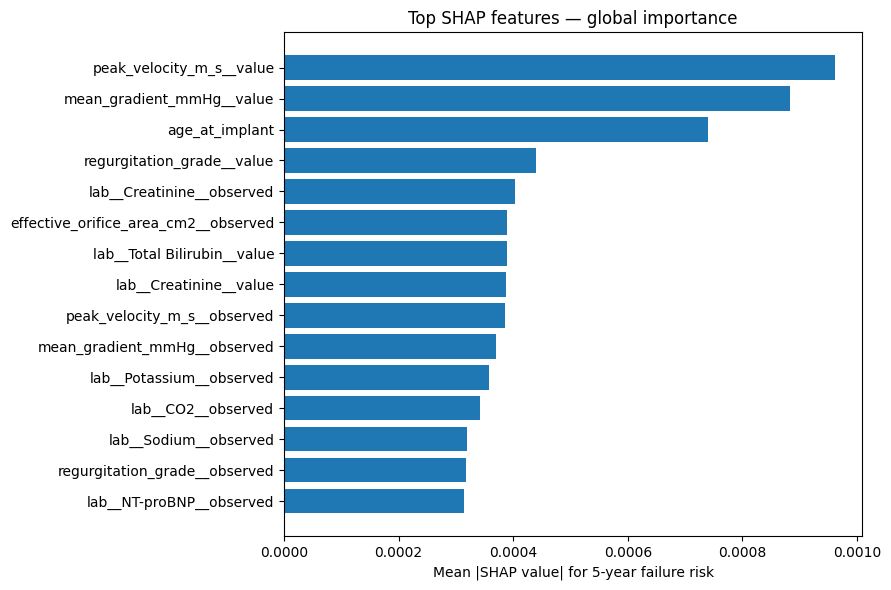

In [11]:
top = global_importance.head(15).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(
    top["feature"],
    top["importance"],
)
plt.xlabel("Mean |SHAP value| for 5-year failure risk")
plt.title("Top SHAP features — global importance")
plt.tight_layout()
plt.show()


## 10. Branch-level importance

This summarizes total SHAP magnitude by modality.

It is **not the same as an ablation study**.  
It tells us how much contribution magnitude the model assigns to each branch in the explained sample.


,branch,importance
1,physiology,0.012158
2,static,0.002690
0,medications,0.000673


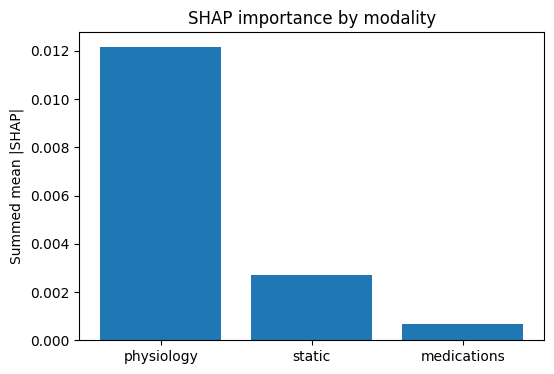

In [12]:
branch_importance = (
    global_importance
    .groupby("branch", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(branch_importance)

plt.figure(figsize=(6,4))
plt.bar(
    branch_importance["branch"],
    branch_importance["importance"],
)
plt.ylabel("Summed mean |SHAP|")
plt.title("SHAP importance by modality")
plt.show()


## 11. Patient-level explanation

For one test patient, temporal SHAP values are summed over time.

Positive SHAP values increase predicted 5-year failure risk.  
Negative values decrease predicted 5-year failure risk.


Patient: SYN_00245
Predicted 5-year risk: 7.152557373046875e-05


,feature,shap,branch,abs_shap
14,peak_velocity_m_s__value,-0.003606,physiology,0.003606
13,mean_gradient_mmHg__value,-0.003238,physiology,0.003238
47,mean_gradient_mmHg__observed,-0.001745,physiology,0.001745
49,effective_orifice_area_cm2__observed,-0.001628,physiology,0.001628
16,regurgitation_grade__value,-0.001601,physiology,0.001601
27,lab__Creatinine__value,-0.001379,physiology,0.001379
15,effective_orifice_area_cm2__value,-0.001294,physiology,0.001294
58,lab__CO2__observed,-0.001178,physiology,0.001178
82,note_valve_dysfunction,-0.001129,physiology,0.001129
24,lab__CO2__value,-0.001108,physiology,0.001108


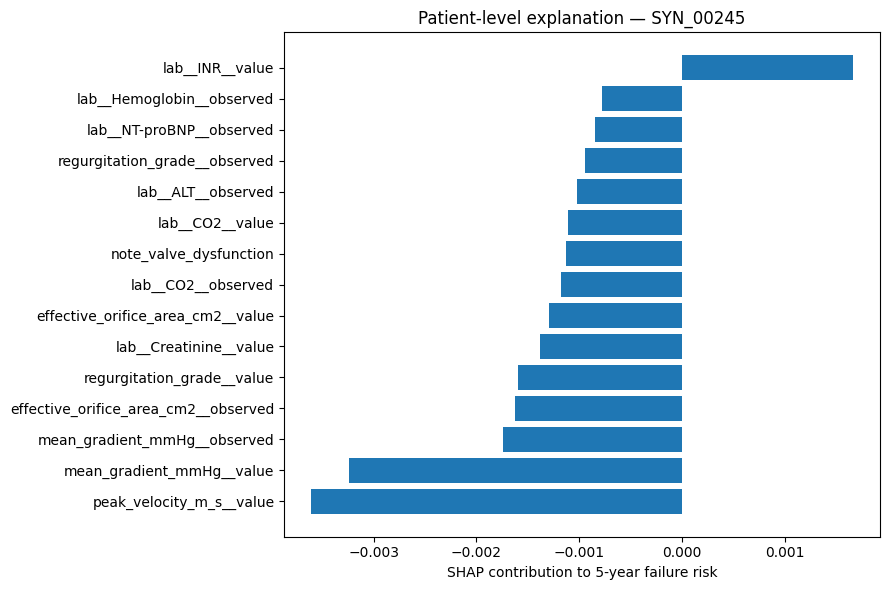

In [13]:
PATIENT_INDEX = 0

pid = test["pid"][explain_idx[PATIENT_INDEX]]

patient_static = sv_static[PATIENT_INDEX]
patient_phys = sv_phys[PATIENT_INDEX].sum(axis=0)
patient_med = sv_med[PATIENT_INDEX].sum(axis=0)

patient_explanation = pd.concat([
    pd.DataFrame({
        "feature": STATIC_INPUT_NAMES,
        "shap": patient_static,
        "branch": "static",
    }),
    pd.DataFrame({
        "feature": PHYS_INPUT_NAMES,
        "shap": patient_phys,
        "branch": "physiology",
    }),
    pd.DataFrame({
        "feature": MED_INPUT_NAMES,
        "shap": patient_med,
        "branch": "medications",
    }),
], ignore_index=True)

patient_explanation["abs_shap"] = patient_explanation["shap"].abs()

top_patient = (
    patient_explanation
    .sort_values("abs_shap", ascending=False)
    .head(15)
    .sort_values("shap")
)

print("Patient:", pid)
print(
    "Predicted 5-year risk:",
    float(
        risk_model.predict(
            [
                test["xs"][explain_idx[PATIENT_INDEX]:explain_idx[PATIENT_INDEX]+1],
                test["xp"][explain_idx[PATIENT_INDEX]:explain_idx[PATIENT_INDEX]+1],
                test["xm"][explain_idx[PATIENT_INDEX]:explain_idx[PATIENT_INDEX]+1],
            ],
            verbose=0,
        )[0,0]
    )
)

display(top_patient)

plt.figure(figsize=(9,6))
plt.barh(
    top_patient["feature"],
    top_patient["shap"],
)
plt.xlabel("SHAP contribution to 5-year failure risk")
plt.title(f"Patient-level explanation — {pid}")
plt.tight_layout()
plt.show()


## 12. Save SHAP outputs

In [14]:
OUTDIR = Path("shap_outputs_v1")
OUTDIR.mkdir(parents=True, exist_ok=True)

global_importance.to_csv(
    OUTDIR / "global_shap_importance_5y.csv",
    index=False,
)

branch_importance.to_csv(
    OUTDIR / "branch_shap_importance_5y.csv",
    index=False,
)

patient_explanation.to_csv(
    OUTDIR / f"patient_shap_{pid}_5y.csv",
    index=False,
)

print("Saved SHAP tables to:", OUTDIR.resolve())


Saved SHAP tables to: C:\Users\User\OneDrive\Υπολογιστής\πανεπιστημιο\workstation\docathon\shap_outputs_v1


# How to present the SHAP analysis

A concise interpretation for the project:

> SHAP analysis was used to explain the model's predicted 5-year bioprosthetic valve failure risk. Global SHAP importance identifies which static, physiological/hemodynamic, and medication features contributed most strongly to predictions. Patient-level SHAP explanations show which variables increased or decreased predicted risk for an individual patient.

### Important caveat

Because the cohort is synthetic, SHAP results show which variables the **synthetic-trained model** learned to use. They should not be interpreted as clinical causal relationships or validated clinical risk factors.


C:\Users\User\AppData\Local\Temp\ipykernel_4620\2787086724.py:134: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


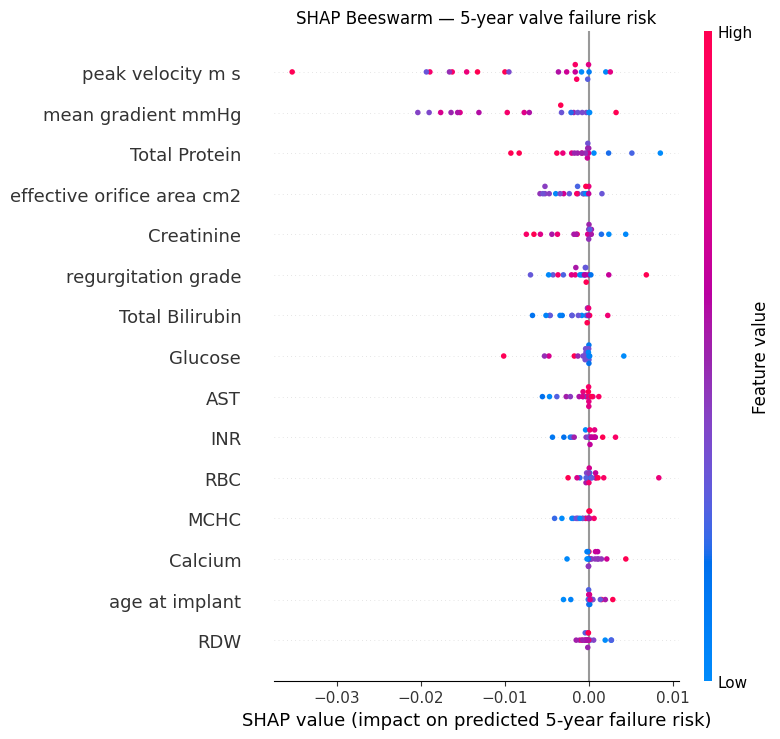

In [15]:
# =========================
# SHAP BEESWARM-STYLE PLOT
# =========================

# We will aggregate temporal SHAP values per patient.
# For physiology and medications:
#   - sum SHAP contributions across time
#   - summarize feature value across time using the mean of observed/value channel

# ---------- STATIC ----------
static_shap_patient = sv_static.copy()

# Values actually fed to the model for the explained patients
static_values_patient = test["xs"][explain_idx].copy()

static_df_shap = pd.DataFrame(
    static_shap_patient,
    columns=STATIC_INPUT_NAMES
)

static_df_values = pd.DataFrame(
    static_values_patient,
    columns=STATIC_INPUT_NAMES
)


# ---------- PHYSIOLOGY ----------
# First len(PHYS_FEATURES) channels are the actual standardized values
n_phys_values = len(PHYS_FEATURES)

# SHAP contribution summed across time
phys_shap_patient = sv_phys[:, :, :n_phys_values].sum(axis=1)

# Model input values averaged across time
phys_values_patient = (
    test["xp"][explain_idx, :, :n_phys_values]
    .mean(axis=1)
)

phys_names_clean = PHYS_FEATURES

phys_df_shap = pd.DataFrame(
    phys_shap_patient,
    columns=phys_names_clean
)

phys_df_values = pd.DataFrame(
    phys_values_patient,
    columns=phys_names_clean
)


# ---------- MEDICATIONS ----------
n_med_values = len(MED_FEATURES)

med_shap_patient = sv_med[:, :, :n_med_values].sum(axis=1)

med_values_patient = (
    test["xm"][explain_idx, :, :n_med_values]
    .mean(axis=1)
)

med_names_clean = MED_FEATURES

med_df_shap = pd.DataFrame(
    med_shap_patient,
    columns=med_names_clean
)

med_df_values = pd.DataFrame(
    med_values_patient,
    columns=med_names_clean
)


# ---------- COMBINE ----------
shap_combined = pd.concat(
    [
        static_df_shap,
        phys_df_shap,
        med_df_shap,
    ],
    axis=1
)

values_combined = pd.concat(
    [
        static_df_values,
        phys_df_values,
        med_df_values,
    ],
    axis=1
)


# ---------- CLEAN LABELS ----------
def clean_feature_name(x):
    return (
        x.replace("lab__", "")
         .replace("med__", "")
         .replace("__present", "")
         .replace("_", " ")
    )

clean_names = [
    clean_feature_name(c)
    for c in shap_combined.columns
]


# ---------- SELECT TOP FEATURES ----------
mean_abs_shap = np.abs(
    shap_combined.to_numpy()
).mean(axis=0)

top_n = 15

top_idx = np.argsort(
    mean_abs_shap
)[-top_n:]

top_features = shap_combined.columns[top_idx]

X_shap = shap_combined[top_features].to_numpy()
X_values = values_combined[top_features].to_numpy()

top_clean_names = [
    clean_feature_name(c)
    for c in top_features
]


# ---------- BEESWARM ----------
shap.summary_plot(
    X_shap,
    X_values,
    feature_names=top_clean_names,
    plot_type="dot",
    max_display=top_n,
    show=False
)

plt.title(
    "SHAP Beeswarm — 5-year valve failure risk"
)

plt.xlabel(
    "SHAP value (impact on predicted 5-year failure risk)"
)

plt.tight_layout()
plt.show()

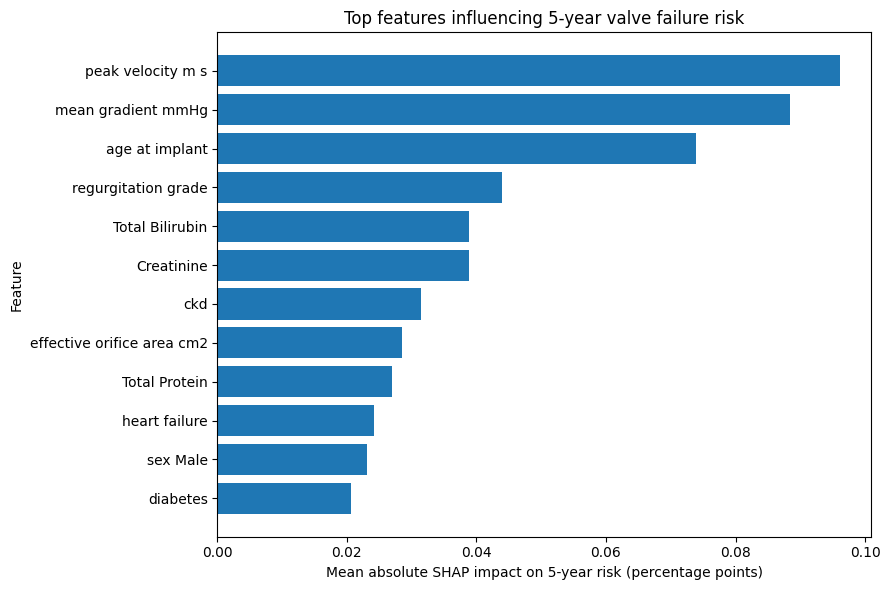

In [17]:
# Top SHAP features — cleaner presentation figure

top_n = 12

plot_df = (
    global_importance
    .copy()
)

# Keep actual clinical value channels only
plot_df = plot_df[
    ~plot_df["feature"].str.contains("__observed", regex=False)
]

plot_df = plot_df[
    plot_df["feature"] != "time_since_implant"
]

plot_df["feature_clean"] = (
    plot_df["feature"]
    .str.replace("lab__", "", regex=False)
    .str.replace("med__", "", regex=False)
    .str.replace("__present", "", regex=False)
    .str.replace("__value", "", regex=False)
    .str.replace("_", " ", regex=False)
)

plot_df = (
    plot_df
    .sort_values("importance", ascending=False)
    .head(top_n)
    .sort_values("importance")
)

plt.figure(figsize=(9, 6))

plot_df["importance_pct_points"] = plot_df["importance"] * 100

plt.barh(
    plot_df["feature_clean"],
    plot_df["importance_pct_points"]
)

plt.xlabel("Mean absolute SHAP impact on 5-year risk (percentage points)")

plt.ylabel("Feature")
plt.title("Top features influencing 5-year valve failure risk")

plt.tight_layout()
plt.show()